In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
df = pd.read_csv("population_by_country_2020.csv")

In [23]:
df.head()

,Country,Population,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share
0,China,1440297825,0.39 %,5540090,153,9388211,-348399.0,1.7,38,61 %,18.47 %
1,India,1382345085,0.99 %,13586631,464,2973190,-532687.0,2.2,28,35 %,17.70 %
2,United States,331341050,0.59 %,1937734,36,9147420,954806.0,1.8,38,83 %,4.25 %
3,Indonesia,274021604,1.07 %,2898047,151,1811570,-98955.0,2.3,30,56 %,3.51 %
4,Pakistan,221612785,2.00 %,4327022,287,770880,-233379.0,3.6,23,35 %,2.83 %


In [24]:
df_copy = df.copy()

In [25]:
df["Yearly Change"] = df["Yearly Change"].str.split(" ").str[0]

In [32]:
df["Yearly Change"] = df["Yearly Change"].astype(float)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          235 non-null    str    
 1   Population       235 non-null    int64  
 2   Yearly Change    235 non-null    float64
 3   Net Change       235 non-null    int64  
 4   Density (P/Km²)  235 non-null    int64  
 5   Land Area (Km²)  235 non-null    int64  
 6   Migrants (net)   201 non-null    float64
 7   Fert. Rate       235 non-null    str    
 8   Med. Age         235 non-null    str    
 9   Urban Pop %      235 non-null    str    
 10  World Share      235 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 20.3 KB


In [47]:
df.head()

,Country,Population,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share
0,China,1440297825,0.39,5540090,153,9388211,-348399.0,1.7,38,61 %,18.47 %
1,India,1382345085,0.99,13586631,464,2973190,-532687.0,2.2,28,35 %,17.70 %
2,United States,331341050,0.59,1937734,36,9147420,954806.0,1.8,38,83 %,4.25 %
3,Indonesia,274021604,1.07,2898047,151,1811570,-98955.0,2.3,30,56 %,3.51 %
4,Pakistan,221612785,2.00,4327022,287,770880,-233379.0,3.6,23,35 %,2.83 %


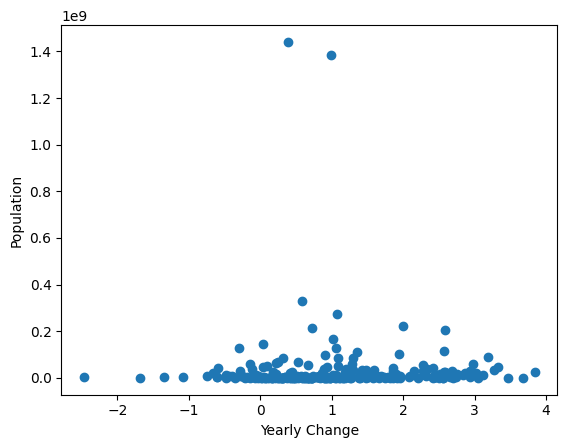

In [35]:
plt.scatter(df['Yearly Change'],df['Population'])
plt.xlabel("Yearly Change")
plt.ylabel("Population")
plt.show()

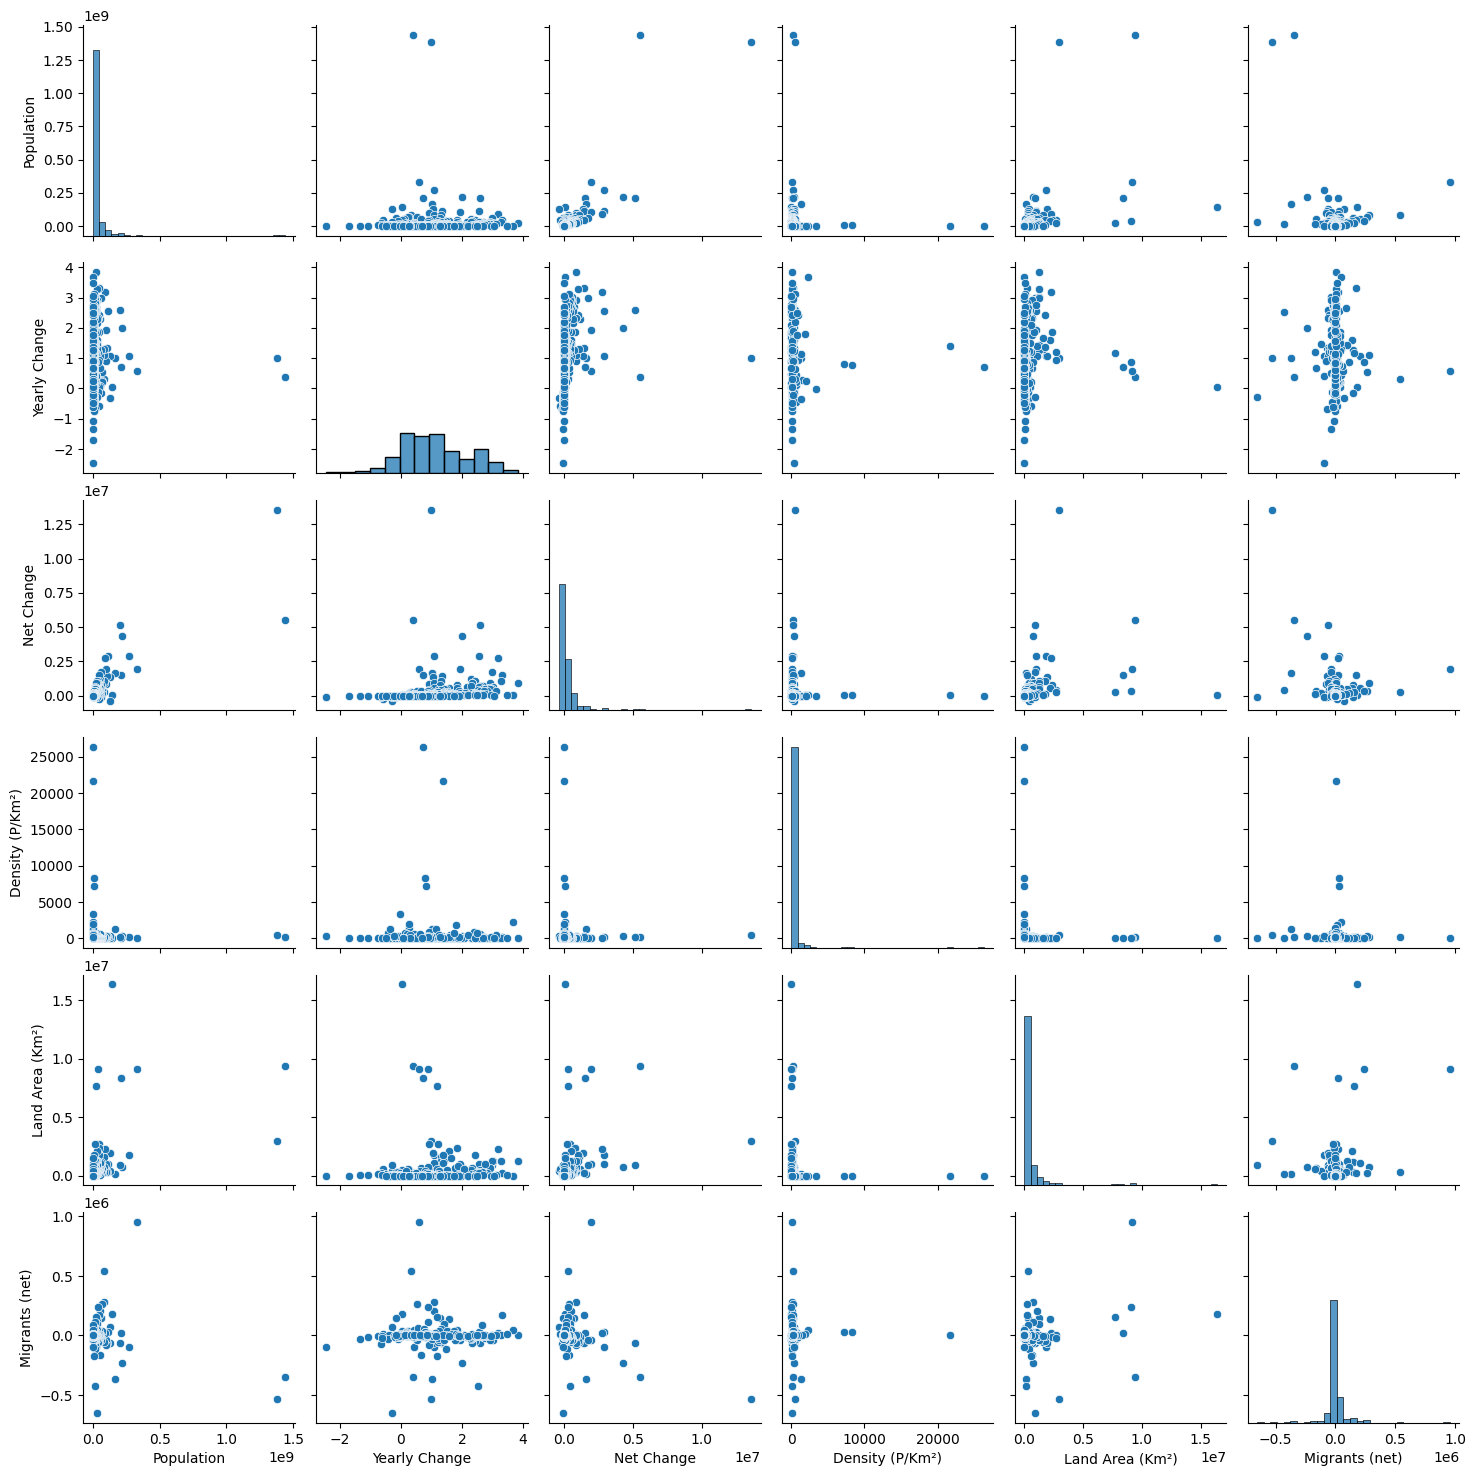

In [36]:
import seaborn as sns
sns.pairplot(df)

In [37]:
X = df[['Yearly Change']]
y = df['Population']

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
coeff=regression.coef_
print(coeff)
intercept = regression.intercept_
print(intercept)

[-4033128.04701412]
38536373.07386363


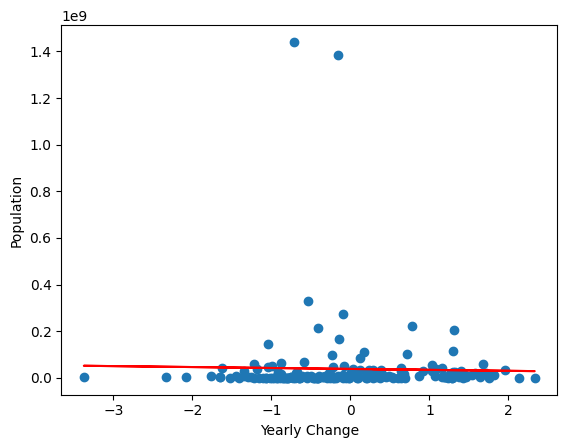

In [43]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')
plt.xlabel("Yearly Change")
plt.ylabel("Population")
plt.show()

In [44]:
y_pred = regression.predict(X_test)


In [46]:
new_data = scaler.transform([[0.39]])
regression.predict(new_data)

s:\AIML Courses\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([41438373.22258782])

In [48]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [49]:
print(mse)
print(mae)
print(rmse)
print(r2)

1471887179730324.0
35555108.40778619
38365181.86755178
-0.5605839269506441


In [50]:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()
predictions = model.predict(X_test)
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:             Population   R-squared (uncentered):                   0.001
Model:                            OLS   Adj. R-squared (uncentered):             -0.005
Method:                 Least Squares   F-statistic:                             0.1122
Date:                Wed, 22 Apr 2026   Prob (F-statistic):                       0.738
Time:                        20:42:40   Log-Likelihood:                         -3573.7
No. Observations:                 176   AIC:                                      7149.
Df Residuals:                     175   BIC:                                      7153.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [51]:
regression.coef_

array([-4033128.04701412])

In [52]:
-4.033e+06 

-4033000.0